[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/11_numpy_indexing_slicing.ipynb)


# NumPy : indexing, slicing et masques booléens

Le notebook précédent a montré comment créer des tableaux. Celui-ci montre
comment en atteindre une partie un élément, une ligne, une région, ou tous les
éléments qui satisfont une condition.

C'est la compétence la plus utilisée au quotidien. Le masque booléen, notamment,
est exactement ce qu'on employait déjà en Pandas avec `data[data['age'] < 18]`.

## Le plan

| Section | Le sujet |
|---|---|
| 1 | Atteindre un élément |
| 2 | Lignes et colonnes : la confusion classique |
| 3 | Le slicing à deux dimensions |
| 4 | Vue ou copie : le piège central |
| 5 | Écrire dans une tranche |
| 6 | Le pas, et les motifs |
| 7 | Les masques booléens |
| 8 | Une image est un tableau |

## Deux pièges annoncés

`A[:, 0]` et `A[0, :]` ne donnent pas la même chose, et l'un des deux n'est pas
ce qu'on croit.

Et un slice NumPy est une vue : modifier une tranche modifie le tableau
d'origine. C'est le contraire des listes Python.

Prérequis : le notebook 10.

## 1. Atteindre un élément

Avec un tableau à deux dimensions, il faut deux indices : la ligne, puis la
colonne.

In [1]:
import numpy as np

A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

print(A)
print()
print('A[0, 0] =', A[0, 0]) # ligne 0, colonne 0
print('A[0, 1] =', A[0, 1]) # ligne 0, colonne 1
print('A[1, 1] =', A[1, 1]) # ligne 1, colonne 1
print('A[2, 0] =', A[2, 0]) # ligne 2, colonne 0

[[1 2 3]
 [4 5 6]
 [7 8 9]]

A[0, 0] = 1
A[0, 1] = 2
A[1, 1] = 5
A[2, 0] = 7


L'ordre est toujours ligne puis colonne, comme en mathématiques. Et les
indices commencent à 0, comme partout en Python.

Les indices négatifs comptent depuis la fin :

In [2]:
print('A[-1, -1] =', A[-1, -1]) # dernier élément
print('A[-1, 0]  =', A[-1, 0])  # première colonne de la dernière ligne

A[-1, -1] = 9
A[-1, 0]  = 7


### La différence avec les listes Python

Une liste de listes exige deux paires de crochets. NumPy accepte les deux
écritures, mais la virgule est préférable.

In [3]:
liste = [[1, 2, 3], [4, 5, 6]]
print('liste :', liste[1][2])

print('numpy :', A[1][2]) # fonctionne
print('numpy :', A[1, 2]) # préférable

liste : 6
numpy : 6
numpy : 6


`A[1][2]` construit d'abord la ligne 1 comme tableau intermédiaire, puis y prend
l'élément 2. `A[1, 2]` accède directement. La différence de vitesse est réelle sur
de gros volumes, et la virgule est la seule forme qui marche avec le slicing à
deux dimensions.

## 2. Lignes et colonnes : la confusion classique

Voici l'erreur que tout le monde commet en commençant.

In [4]:
print('A[:, 0] =', A[:, 0])
print('A[0, :] =', A[0, :])

A[:, 0] = [1 4 7]
A[0, :] = [1 2 3]


Lequel est la première ligne ?

`A[0, :]` donne `[1 2 3]` c'est la première ligne. On fixe la ligne à 0 et
on prend toutes les colonnes.

`A[:, 0]` donne `[1 4 7]` c'est la première colonne. On prend toutes les
lignes, et on fixe la colonne à 0.

Le moyen de ne plus se tromper : lire dans l'ordre. Ce qui est avant la
virgule concerne les lignes, ce qui est après concerne les colonnes. Le `:`
signifie « tout ».

In [5]:
print('A[0, :] -> ligne 0 :', A[0, :])
print('A[:, 0] -> colonne 0  :', A[:, 0])
print()
print('A[0] est un raccourci de A[0, :] :', A[0])

A[0, :] -> ligne 0 : [1 2 3]
A[:, 0] -> colonne 0  : [1 4 7]

A[0] est un raccourci de A[0, :] : [1 2 3]


Omettre la partie après la virgule sous-entend « toutes les colonnes ». `A[0]`
et `A[0, :]` sont identiques.

Il n'existe pas de raccourci équivalent pour les colonnes : `A[:, 0]` s'écrit en
entier.

### La forme du résultat

Attention, extraire une ligne ou une colonne donne toujours un tableau à une
dimension.

In [6]:
print('A[0, :] shape :', A[0, :].shape)
print('A[:, 0] shape :', A[:, 0].shape)
print()
print('A[0:1, :] shape :', A[0:1, :].shape) # avec un slice : 2D conservé
print('A[:, 0:1] shape :', A[:, 0:1].shape)

A[0, :] shape : (3,)
A[:, 0] shape : (3,)

A[0:1, :] shape : (1, 3)
A[:, 0:1] shape : (3, 1)


C'est le piège `(3,)` contre `(3, 1)` du notebook 10, sous une nouvelle forme.

Un indice supprime la dimension. Un slice, même d'un seul élément, la
conserve.

C'est important quand une fonction exige une matrice : `A[:, 0]` donnera une
erreur de dimension là où `A[:, 0:1]` passera. L'autre solution est le
`reshape(-1, 1)`.

## 3. Le slicing à deux dimensions

La syntaxe complète est `A[début:fin, début:fin]`, avec les mêmes règles que le
slicing de listes du notebook 04 : borne de fin exclue, parties facultatives.

In [9]:
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print('A[0:2, 0:2] : les 2 premières lignes et colonnes')
print(A[0:2, 0:2])

A[0:2, 0:2] : les 2 premières lignes et colonnes
[[1 2]
 [4 5]]


In [12]:
print('A[:, 1:3] :')
print(A[:, 1:3])

print()
print('A[:, 1:] : identique, la fin est sous-entendue')
print(A[:, 1:])

print()
print('égaux ?', np.array_equal(A[:, 1:], A[:, 1:3]))

A[:, 1:3] :
[[2 3]
 [5 6]
 [8 9]]

A[:, 1:] : identique, la fin est sous-entendue
[[2 3]
 [5 6]
 [8 9]]

égaux ? True


Note l'usage de `np.array_equal` plutôt que `==`. La comparaison directe renvoie
un tableau de booléens, pas un booléen unique :

In [13]:
print('A[:, 1:] == A[:, 1:3] donne :')
print(A[:, 1:] == A[:, 1:3])
print()
print('.all() résume :', (A[:, 1:] == A[:, 1:3]).all())

A[:, 1:] == A[:, 1:3] donne :
[[ True  True]
 [ True  True]
 [ True  True]]

.all() résume : True


C'est pour cela qu'un `if tableau1 == tableau2` lève une erreur : Python ne sait
pas quoi faire d'un tableau de booléens dans une condition. Il faut `.all()` ou
`.any()`.

### Les indices négatifs

In [14]:
print('A[:, -2:] : les 2 dernières colonnes')
print(A[:, -2:])

print()
print('A[-1, :] : la dernière ligne')
print(A[-1, :])

A[:, -2:] : les 2 dernières colonnes
[[2 3]
 [5 6]
 [8 9]]

A[-1, :] : la dernière ligne
[7 8 9]


`A[:, -2:]` est plus robuste que `A[:, 1:3]` : il donne les deux dernières
colonnes quelle que soit la largeur du tableau.

## 4. Vue ou copie : le piège central

Voici la différence la plus importante entre les listes Python et les tableaux
NumPy.

In [15]:
liste = [1, 2, 3, 4]
morceau = liste[1:3]
morceau[0] = 99

print('Liste Python :', liste, '-> inchangée')

Liste Python : [1, 2, 3, 4] -> inchangée


In [16]:
tableau = np.array([1, 2, 3, 4])
morceau = tableau[1:3]
morceau[0] = 99

print('Tableau NumPy :', tableau, '-> MODIFIÉ')

Tableau NumPy : [ 1 99  3  4] -> MODIFIÉ


Un slice de liste crée une copie. Un slice NumPy crée une vue : elle partage
la mémoire du tableau d'origine.

C'est un choix de performance. Copier un million de valeurs coûte cher ; une vue
ne coûte rien, elle mémorise juste où regarder.

In [17]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

B = A[0:2, 0:2]
print('B partage la mémoire de A :', B.base is A)

B[0, 0] = 99
print()
print('B :'); print(B)
print('A :'); print(A)

B partage la mémoire de A : True

B :
[[99  2]
 [ 4  5]]
A :
[[99  2  3]
 [ 4  5  6]
 [ 7  8  9]]


L'attribut `base` désigne le tableau d'origine quand il s'agit d'une vue, et vaut
`None` sinon. C'est le moyen de vérifier.

Pour obtenir une vraie copie, il faut le demander :

In [18]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

B = A[0:2, 0:2].copy()
print('B est indépendant :', B.base is None)

B[0, 0] = 99
print('A intact :')
print(A)

B est indépendant : True
A intact :
[[1 2 3]
 [4 5 6]
 [7 8 9]]


C'est le `.copy()` déjà rencontré sur les listes et les DataFrames. Le réflexe
est le même : copier avant de modifier, sauf si le partage est voulu.

### Une exception : l'indexing par liste

Passer une liste d'indices renvoie une copie, pas une vue.

In [19]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

vue = A[0:2] # slice -> vue
copie = A[[0, 1]] # liste d'indices -> copie

print('slice -> vue :', vue.base is A)
print('liste -> copie :', copie.base is None)

copie[0, 0] = 99
print()
print('A intact :', A[0, 0])

slice -> vue : True
liste -> copie : True

A intact : 1


Cette sélection par liste s'appelle le *fancy indexing*. Elle permet de choisir
des lignes dans n'importe quel ordre :

```python
A[[2, 0, 1]] # réordonne les lignes
A[[0, 0, 0]] # répète la même ligne
```

La distinction vue/copie n'est pas intuitive : slice donne une vue, liste donne
une copie. Le réflexe est de vérifier avec `.base` en cas de doute.

## 5. Écrire dans une tranche

L'affectation fonctionne sur n'importe quelle sélection.

In [20]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

A[0:2, 0:2] = 10
print(A)

[[10 10  3]
 [10 10  6]
 [ 7  8  9]]


La valeur unique est diffusée à toutes les cases de la sélection. C'est du
broadcasting, le sujet du notebook 13.

On peut aussi affecter un tableau, à condition que les formes soient compatibles :

In [21]:
A = np.zeros((3, 3))

A[0, :] = [1, 2, 3] # une ligne entière
A[:, 2] = 9 # une colonne entière
A[1:3, 0:2] = [[7, 7], [8, 8]] # un bloc

print(A)

[[1. 2. 9.]
 [7. 7. 9.]
 [8. 8. 9.]]


### Dessiner des motifs

Un cas classique pour comprendre le slicing : construire une forme.

In [22]:
B = np.zeros((5, 5))
B[1:4, 1:4] = 1

print(B)

[[0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]


In [23]:
C = np.zeros((5, 5))
C[::2, ::2] = 1 # une ligne sur deux, une colonne sur deux

print(C)

[[1. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 1.]]


Le pas `::2` prend un élément sur deux, dans les deux dimensions. Le résultat est
un damier partiel.

Pour un vrai damier, il faut deux affectations :

In [24]:
damier = np.zeros((6, 6))
damier[::2, ::2] = 1 # cases paires-paires
damier[1::2, 1::2] = 1 # cases impaires-impaires

print(damier)

[[1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1.]]


Le `1::2` démarre à l'indice 1 et avance de 2. C'est la même syntaxe que le
slicing de listes du notebook 04.

Attention : comme un slice est une vue, écrire dedans écrit dans le tableau
d'origine. C'est justement ce qu'on veut ici, mais ça surprend quand on ne s'y
attend pas :

```python
sous_partie = A[0:2]
sous_partie[:] = 0 # met à zéro dans A aussi
```

## 6. Les masques booléens

C'est la partie la plus utile du notebook.

Une comparaison sur un tableau produit un tableau de booléens, de même forme.

In [25]:
np.random.seed(0)
A = np.random.randint(0, 10, (5, 5))

print(A)
print()
print(A < 5)

[[5 0 3 3 7]
 [9 3 5 2 4]
 [7 6 8 8 1]
 [6 7 7 8 1]
 [5 9 8 9 4]]

[[False  True  True  True False]
 [False  True False  True  True]
 [False False False False  True]
 [False False False False  True]
 [False False False False  True]]


Chaque case répond à la question « cette valeur est-elle inférieure à 5 ».

Ce tableau de booléens peut ensuite servir de filtre :

In [26]:
print('A[A < 5] :', A[A < 5])
print('forme :', A[A < 5].shape)

A[A < 5] : [0 3 3 3 2 4 1 1 4]
forme : (9,)


Le résultat est toujours à une dimension, quelle que soit la forme du tableau
d'origine. C'est logique : les valeurs sélectionnées ne forment pas
nécessairement un rectangle.

C'est exactement le mécanisme du filtrage Pandas :

```python
data[data['age'] < 18]
```

### Écrire à travers un masque

In [28]:
np.random.seed(0)
A = np.random.randint(0, 10, (5, 5))
print('avant :'); print(A)

A[A < 5] = 0
print()
print('après :'); print(A)

avant :
[[5 0 3 3 7]
 [9 3 5 2 4]
 [7 6 8 8 1]
 [6 7 7 8 1]
 [5 9 8 9 4]]

après :
[[5 0 0 0 7]
 [9 0 5 0 0]
 [7 6 8 8 0]
 [6 7 7 8 0]
 [5 9 8 9 0]]


Toutes les valeurs inférieures à 5 sont mises à zéro, en une ligne, sans boucle.

C'est la vectorisation du notebook 10 appliquée à une condition.

### Combiner des conditions

Il faut `&`, `|` et `~`, avec des parenthèses obligatoires.

In [31]:
np.random.seed(0)
A = np.random.randint(0, 10, (5, 5))

masque = (A > 2) & (A < 7)
print('Valeurs entre 3 et 6 :', A[masque])
print()
print('Négation ~ :', A[~masque][:8], '...')

Valeurs entre 3 et 6 : [5 3 3 3 5 4 6 6 5 4]

Négation ~ : [0 7 9 2 7 8 8 1] ...


Pourquoi pas `and` ? Parce que `and` travaille sur une seule valeur booléenne,
alors qu'ici on compare des tableaux entiers, élément par élément.

In [32]:
try:
    A[(A > 2) and (A < 7)]
except ValueError as e:
    print('ValueError :', str(e)[:80])

ValueError : The truth value of an array with more than one element is ambiguous. Use a.any()


Le message parle d'ambiguïté : Python ne sait pas si un tableau de booléens doit
compter comme vrai ou faux.

C'est le point de comparaison `and` / `&` du notebook 02, et c'est aussi pourquoi
Pandas exige la même syntaxe :

```python
data[(data['age'] < 18) & (data['pclass'] == 3)]
```

Les parenthèses ne sont pas facultatives : `&` a une priorité plus forte que
`<` et `>`, donc `A > 2 & A < 7` serait interprété à l'envers.

### Un masque venu d'un autre tableau

Le masque n'a pas besoin de venir du tableau qu'on filtre. Seule la forme
doit correspondre.

In [33]:
np.random.seed(0)
A = np.random.randint(0, 10, (5, 5))
B = np.random.randn(5, 5)

selection = B[A > 5]

print('Valeurs de B là où A dépasse 5 :')
print(selection.round(3))
print('nombre :', selection.size, 'sur', A.size)

Valeurs de B là où A dépasse 5 :
[ 0.313 -0.854  2.27  -1.454  0.046 -0.187  1.469  0.155  0.378 -0.888
  0.156  1.23   1.202]
nombre : 13 sur 25


C'est très puissant : on sélectionne dans un tableau selon une condition portant
sur un autre.

L'usage typique en machine learning : `X[y == 0]` sélectionne les individus de la
classe 0. C'est ce qu'on faisait dans les exercices Pandas avec
`data[data['sex'] == 'female']`.

### Compter sans filtrer

In [35]:
np.random.seed(0)
A = np.random.randint(0, 10, (5, 5))

print('Combien de valeurs < 5 :', (A < 5).sum())
print('Proportion :', (A < 5).mean().round(3))
print('Y en a-t-il au moins une :', (A < 5).any())
print('Toutes le sont-elles :', (A < 5).all())

Combien de valeurs < 5 : 9
Proportion : 0.36
Y en a-t-il au moins une : True
Toutes le sont-elles : False


`sum` sur des booléens les compte, puisque `True` vaut 1 l'idiome du notebook
07. Et `mean` donne directement la proportion.

C'est pour cette raison que `data['survived'].mean()` donnait le taux de survie.

### np.where : choisir selon une condition

In [36]:
np.random.seed(0)
A = np.random.randint(0, 10, (3, 4))

print(A)
print()
print("np.where(A > 5, 'grand', 'petit') :")
print(np.where(A > 5, 'grand', 'petit'))
print()
print('Version numérique :')
print(np.where(A > 5, A, 0))

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]

np.where(A > 5, 'grand', 'petit') :
[['petit' 'petit' 'petit' 'petit']
 ['grand' 'grand' 'petit' 'petit']
 ['petit' 'petit' 'grand' 'grand']]

Version numérique :
[[0 0 0 0]
 [7 9 0 0]
 [0 0 7 6]]


`np.where(condition, si_vrai, si_faux)` est l'équivalent vectorisé du `if`
ternaire du notebook 06. Il conserve la forme du tableau, contrairement au
filtrage qui l'aplatit.

## 7. Une image est un tableau

C'est la démonstration la plus parlante du slicing.

type : <class 'numpy.ndarray'>
forme : (768, 1024, 3)
ndim : 3
dtype : uint8
min, max : 0 255


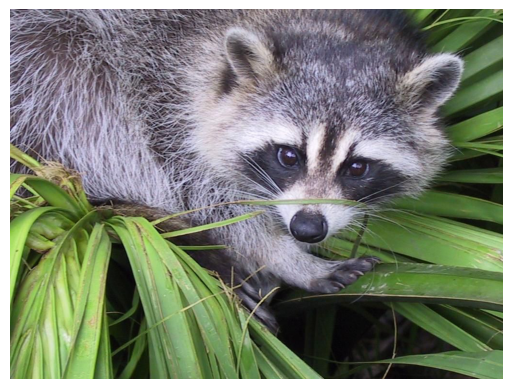

In [38]:
# Sur Colab, pooch est nécessaire pour télécharger l'image
# !pip install -q pooch

import matplotlib.pyplot as plt

try:
    from scipy import datasets
    face = datasets.face()
except Exception:
    from skimage import data
    face = data.chelsea()  # solution de repli, sans réseau

print('type :', type(face))
print('forme :', face.shape)
print('ndim :', face.ndim)
print('dtype :', face.dtype)
print('min, max :', face.min(), face.max())

plt.imshow(face)
plt.axis('off')
plt.show()

La forme a trois dimensions : hauteur, largeur, et les trois canaux rouge,
vert et bleu.

Le type `uint8` va de 0 à 255. C'est celui qui déborde à 256, comme vu au
notebook 10 additionner deux images sans conversion produit des artefacts.

### Le slicing devient visuel

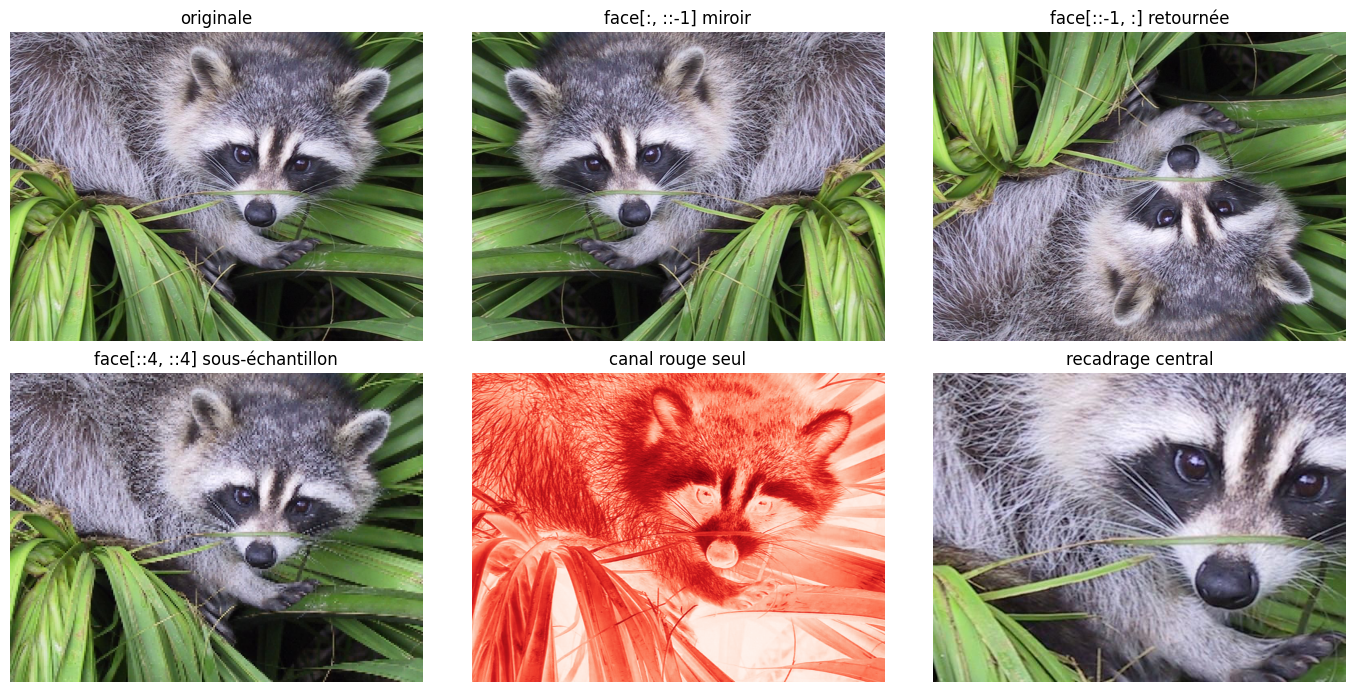

In [39]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7))

ax[0, 0].imshow(face); ax[0, 0].set_title('originale')
ax[0, 1].imshow(face[:, ::-1]); ax[0, 1].set_title('face[:, ::-1] miroir')
ax[0, 2].imshow(face[::-1, :]); ax[0, 2].set_title('face[::-1, :] retournée')
ax[1, 0].imshow(face[::4, ::4]); ax[1, 0].set_title('face[::4, ::4] sous-échantillon')
ax[1, 1].imshow(face[:, :, 0], cmap='Reds');  ax[1, 1].set_title('canal rouge seul')

h, l = face.shape[0], face.shape[1]
ax[1, 2].imshow(face[h//4:3*h//4, l//4:3*l//4]); ax[1, 2].set_title('recadrage central')

for a in ax.flatten():
    a.axis('off')

plt.tight_layout()
plt.show()

Six transformations d'image, toutes obtenues par du slicing pur aucune
bibliothèque de traitement d'image.

`[::-1]` inverse l'ordre, exactement comme sur une liste au notebook 04. Sur le
premier axe, c'est un retournement vertical ; sur le second, un miroir
horizontal.

`[::4, ::4]` ne garde qu'un pixel sur quatre : l'image est seize fois plus
légère, et visiblement pixelisée.

`[:, :, 0]` extrait le premier canal. Le résultat est à deux dimensions, d'où le
`cmap` nécessaire pour l'affichage.

### Le masque booléen sur une image

forme : (768, 1024) -> 2 dimensions


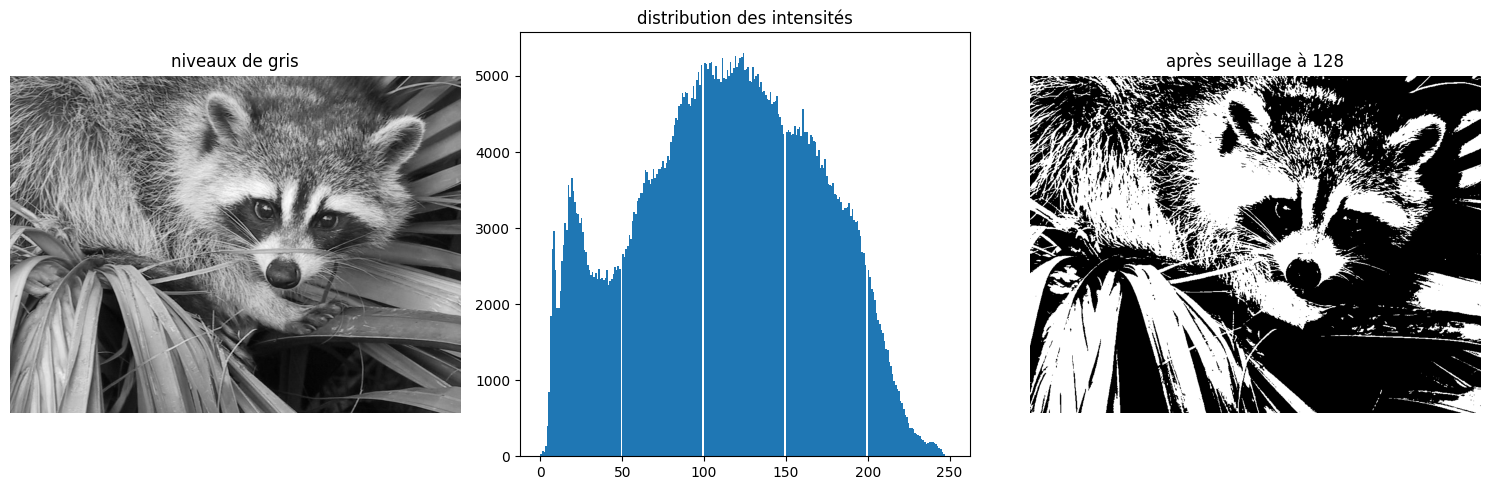

In [40]:
try:
    from scipy import datasets
    gris = datasets.face(gray=True)
except Exception:
    from skimage import data
    gris = data.camera()

print('forme :', gris.shape, '-> 2 dimensions')

seuillee = gris.copy() # copy() : on ne détruit pas l'original
seuillee[seuillee > 128] = 255
seuillee[seuillee <= 128] = 0

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(gris, cmap='gray'); ax[0].set_title('niveaux de gris')
ax[1].hist(gris.ravel(), bins=255); ax[1].set_title('distribution des intensités')
ax[2].imshow(seuillee, cmap='gray'); ax[2].set_title('après seuillage à 128')

ax[0].axis('off'); ax[2].axis('off')
plt.tight_layout()
plt.show()

Le `.copy()` est indispensable ici. Sans lui, on écraserait l'image d'origine et
la comparaison serait impossible c'est le piège de la section 4.

Ce seuillage est exactement celui du notebook SciPy, où il servait à compter des
objets. Et l'histogramme est ce qui permet de choisir le seuil, avec la réserve
qu'on avait découverte : un seuil global échoue quand l'éclairage n'est pas
uniforme.

## 8. Mémo

### Atteindre

| Écriture | Résultat |
|---|---|
| `A[i, j]` | un élément |
| `A[i]` ou `A[i, :]` | la ligne i, forme `(n,)` |
| `A[:, j]` | la colonne j, forme `(m,)` |
| `A[i:i+1, :]` | la ligne i en 2D, forme `(1, n)` |
| `A[a:b, c:d]` | un bloc rectangulaire |
| `A[:, -2:]` | les deux dernières colonnes |
| `A[::2, ::2]` | un élément sur deux |
| `A[::-1]` | lignes inversées |

### Masques

| Écriture | Effet |
|---|---|
| `A < 5` | tableau de booléens, même forme |
| `A[A < 5]` | les valeurs, aplaties en 1D |
| `A[A < 5] = 0` | remplace en place |
| `(A > 2) & (A < 7)` | et logique, parenthèses obligatoires |
| `~masque` | négation |
| `(A < 5).sum()` | combien |
| `(A < 5).mean()` | quelle proportion |
| `np.where(cond, a, b)` | choisit, conserve la forme |
| `B[A > 5]` | filtre B selon une condition sur A |

### Vue ou copie

| Sélection | Résultat |
|---|---|
| `A[0:2]` slice | **vue** |
| `A[[0, 1]]` liste d'indices | copie |
| `A[A > 5]` masque | copie |
| `A[0:2].copy()` | copie |

Vérifier avec `.base is A`.

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `A[:, 0]` pris pour une ligne | c'est une colonne |
| Modifier un slice | modifie le tableau d'origine |
| `A[0]` au lieu de `A[0:1]` | perd une dimension |
| `and` au lieu de `&` | `ValueError` sur l'ambiguïté |
| Oublier les parenthèses | priorité inversée |
| `if A == B` | `ValueError`, il faut `.all()` |

## 9. Exercices

**Exercice 1**

Écris une fonction `encadrer(tableau, epaisseur=1, valeur=0)` qui met à `valeur`
toutes les cases situées sur le bord du tableau, sur l'épaisseur demandée. Le
tableau d'origine ne doit pas être modifié.

Teste sur une matrice 6×6 avec des épaisseurs de 1 et 2.

**Exercice 2**

À partir d'un tableau `(100, 3)` de valeurs normales, écris une fonction
`nettoyer(X, seuil=2)` qui remplace par la médiane de la colonne toutes les
valeurs dont l'écart à la moyenne dépasse `seuil` écarts-types.

Compte combien de valeurs ont été remplacées, colonne par colonne.

**Exercice 3**

Cette fonction contient deux pièges de ce notebook :

```python
def extraire_centre(image, taille=100):
    h, l = image.shape[0], image.shape[1]
    centre = image[h//2 - taille : h//2 + taille,
                   l//2 - taille : l//2 + taille]
    centre[0, :] = 0
    return centre
```

Applique-la à une image, puis réaffiche l'image d'origine. Explique ce que tu
observes, puis corrige la fonction.

Deuxième question : que se passe-t-il si `taille` dépasse la moitié de l'image ?
Teste, et explique pourquoi aucune erreur n'est levée.

## Pour continuer

Le notebook suivant porte sur les mathématiques et les statistiques : `sum`,
`mean`, `std`, et surtout l'argument `axis` celui qui décide si l'on calcule
par ligne ou par colonne.

Puis viendra le broadcasting, qui explique enfin pourquoi `A[:, 0]` de forme
`(5,)` et `A[:, 0:1]` de forme `(5, 1)` ne se comportent pas pareil dans un
calcul.

In [41]:
# Exercice 1

In [42]:
def encadrer(tableau, epaisseur=1, valeur=0):
    """Met à `valeur` les bords du tableau, sur l'épaisseur demandée.

    Retourne un nouveau tableau ; l'original n'est pas modifié.
    """
    if epaisseur < 1:
        return tableau.copy() # sinon [-0:] sélectionne tout

    resultat = tableau.copy()

    resultat[:epaisseur, :] = valeur # bande du haut
    resultat[-epaisseur:, :] = valeur # bande du bas
    resultat[:, :epaisseur] = valeur # bande de gauche
    resultat[:, -epaisseur:] = valeur # bande de droite

    return resultat

In [43]:
A = np.arange(36).reshape(6, 6)

print('épaisseur 1 :'); print(encadrer(A, 1))
print()
print('épaisseur 2 :'); print(encadrer(A, 2))
print()
print('origine intacte :', np.array_equal(A, np.arange(36).reshape(6, 6)))

épaisseur 1 :
[[ 0  0  0  0  0  0]
 [ 0  7  8  9 10  0]
 [ 0 13 14 15 16  0]
 [ 0 19 20 21 22  0]
 [ 0 25 26 27 28  0]
 [ 0  0  0  0  0  0]]

épaisseur 2 :
[[ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0 14 15  0  0]
 [ 0  0 20 21  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]]

origine intacte : True


In [45]:
print('A[-0:] donne :', A[-0:].shape) # (6, 6) — tout le tableau !

A[-0:] donne : (6, 6)


In [46]:
def encadrer_v2(tableau, epaisseur=1, valeur=0):
    resultat = tableau.copy()
    interieur = np.zeros_like(tableau, dtype=bool)
    interieur[epaisseur:-epaisseur, epaisseur:-epaisseur] = True
    resultat[~interieur] = valeur
    return resultat

In [47]:
print(encadrer_v2(A, 1))

[[ 0  0  0  0  0  0]
 [ 0  7  8  9 10  0]
 [ 0 13 14 15 16  0]
 [ 0 19 20 21 22  0]
 [ 0 25 26 27 28  0]
 [ 0  0  0  0  0  0]]


In [48]:
print(encadrer_v2(A, 2))

[[ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0 14 15  0  0]
 [ 0  0 20 21  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]]


In [49]:
# Exercice 2

In [50]:
def nettoyer(X, seuil=2):
    """Remplace les valeurs aberrantes par la médiane de leur colonne.
    Une valeur est aberrante si son écart à la moyenne dépasse
    `seuil` écarts-types.
    Retourne (tableau nettoyé, nombre de remplacements par colonne).
    """
    resultat = X.astype(float).copy()
    remplaces = []

    for j in range(resultat.shape[1]):
        colonne = resultat[:, j] # Vue sur la colonne

        moyenne = colonne.mean()
        ecart_type = colonne.std()
        mediane = np.median(colonne)

        masque = np.abs(colonne - moyenne) > seuil * ecart_type
        remplaces.append(masque.sum())

        colonne[masque] = mediane # écrit dans resultat

    return resultat, remplaces

In [51]:
rng = np.random.default_rng(0)
X = rng.normal(size=(100, 3))

X[5, 0] = 10 # deux valeurs aberrantes injectées
X[20, 1] = -8

propre, compte = nettoyer(X)

print('Remplacements par colonne :', compte)
print()
for j in range(3):
    print(f'colonne {j} : avant [{X[:, j].min():.2f}, {X[:, j].max():.2f}]  '
          f'après [{propre[:, j].min():.2f}, {propre[:, j].max():.2f}]')

Remplacements par colonne : [np.int64(2), np.int64(3), np.int64(3)]

colonne 0 : avant [-2.40, 10.00]  après [-2.40, 2.76]
colonne 1 : avant [-8.00, 2.55]  après [-1.94, 2.35]
colonne 2 : avant [-2.94, 1.96]  après [-1.90, 1.82]


In [52]:
def nettoyer_robuste(X, seuil=3):
    resultat = X.astype(float).copy()
    remplaces = []
    for j in range(resultat.shape[1]):
        colonne = resultat[:, j]
        mediane = np.median(colonne)
        mad = np.median(np.abs(colonne - mediane)) # écart absolu médian
        masque = np.abs(colonne - mediane) > seuil * mad * 1.4826
        remplaces.append(masque.sum())
        colonne[masque] = mediane
    return resultat, remplaces

print('Version robuste :', nettoyer_robuste(X)[1])

Version robuste : [np.int64(1), np.int64(2), np.int64(0)]


In [53]:
def nettoyer_vectorise(X, seuil=2):
    R = X.astype(float).copy()
    moyennes = R.mean(axis=0) # une valeur par colonne
    ecarts = R.std(axis=0)
    medianes = np.median(R, axis=0)

    masque = np.abs(R - moyennes) > seuil * ecarts # broadcasting
    R[masque] = np.broadcast_to(medianes, R.shape)[masque]
    return R, masque.sum(axis=0)

In [54]:
# Exercice 3

In [55]:
def extraire_centre(image, taille=100):
    h, l = image.shape[0], image.shape[1]
    centre = image[h//2 - taille : h//2 + taille,
                   l//2 - taille : l//2 + taille]
    centre[0, :] = 0
    return centre

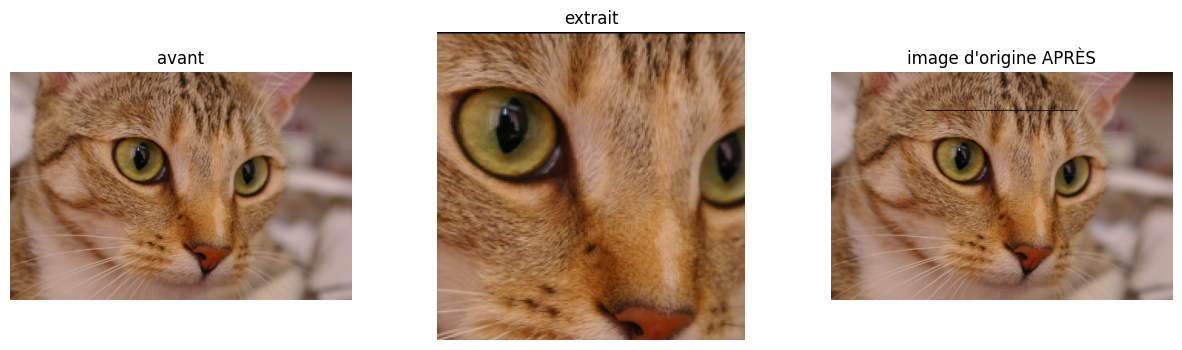

image modifiée ? True


In [56]:
from skimage import data
import matplotlib.pyplot as plt

image = data.chelsea()
original = image.copy()

centre = extraire_centre(image, 100)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(original);  ax[0].set_title('avant')
ax[1].imshow(centre);    ax[1].set_title('extrait')
ax[2].imshow(image);     ax[2].set_title('image d\'origine APRÈS')
for a in ax: a.axis('off')
plt.show()

print('image modifiée ?', not np.array_equal(image, original))

In [57]:
petite = np.arange(100).reshape(10, 10)

print('forme demandée : 200x200 sur une image 10x10')
print('forme obtenue :', extraire_centre(petite, 100).shape)
print()
print('5 - 100 =', 5 - 100)

forme demandée : 200x200 sur une image 10x10
forme obtenue : (10, 10)

5 - 100 = -95


In [58]:
print('petite[0:1000].shape :', petite[0:1000].shape) # tronqué
try:
    petite[1000, 0]
except IndexError as e:
    print('IndexError :', e) # là ça plante

petite[0:1000].shape : (10, 10)
IndexError : index 1000 is out of bounds for axis 0 with size 10


In [60]:
def extraire_centre(image, taille=100):
    """Extrait un carré centré de côté 2*taille.

    Retourne une COPIE ; l'image d'origine n'est pas modifiée.
    Lève ValueError si la taille demandée dépasse l'image.
    """
    h, l = image.shape[0], image.shape[1]

    if taille * 2 > min(h, l):
        raise ValueError(
            f'taille={taille} trop grande pour une image {h}x{l} '
            f'(maximum {min(h, l) // 2})'
        )

    haut, gauche = h // 2 - taille, l // 2 - taille

    centre = image[haut:haut + 2*taille,
                   gauche:gauche + 2*taille].copy() # copie explicite

    centre[0, :] = 0
    return centre

In [61]:
image = data.chelsea()
original = image.copy()

centre = extraire_centre(image, 100)

print('forme extraite  :', centre.shape)
print('origine intacte :', np.array_equal(image, original))

try:
    extraire_centre(image, 500)
except ValueError as e:
    print('ValueError :', e)

forme extraite  : (200, 200, 3)
origine intacte : True
ValueError : taille=500 trop grande pour une image 300x451 (maximum 150)
